# Fixed Income Project

*Leon CHATAIGNAULT, Robin RICROS, Badre MHIOUAH*

## **Table of contents**

### i. Imports
### ii. Utility functions
### 1. Spot rate curve
### 2. Hull-White model
* #### 2.1 Model Calibration
* #### 2.2 Bermudean swaption pricing

## Imports

In [1]:
import numpy as np
import pandas as pd
from math import floor
from matplotlib import pyplot as plt

## Utility functions

In [51]:
def date_factor(unit:str)->float:
    """ Yearly conversion factor """
    match unit:
        case "DY":
            return 360.
        case "MO":
            return 12.
        case "YR":
            return 1.
        
def load_quotes(file_name:str)->pd.DataFrame:
    quotes =  pd.read_excel(file_name)
    quotes["Mid"] = (quotes["Bid"] + quotes["Ask"])/2.
    quotes["Maturity (Y)"] = quotes.apply(year_maturity, axis=1)
    return quotes

def year_maturity(prdt:pd.Series)->float:
    return prdt["Term"]/date_factor(prdt["Unit"])
        
def interpolate(b1:pd.Series, b2:pd.Series, t:float):
    T1 = b1["Maturity (Y)"]
    T2 = b2["Maturity (Y)"]
    rT1 = -np.log(b1["B(0,T)"])/T1
    rT2 = -np.log(b2["B(0,T)"])/T2
    rt = (t-T1)/(T2-T1)*rT2 + (T2-t)/(T2-T1)*rT1
    return np.exp(-rt*t)
    
def get_cash_rate(c_r:pd.Series)->float:
    return 1./(1.+c_r["Mid"]/100.*c_r["Term"]/date_factor(c_r["Unit"]))

def get_FRA_rate_interpolate(f_r:pd.Series, B1, B2)->float:
    # get the FRA starting date
    T = (f_r["Term"] - 6)/12. 
    # define the term
    delta = (f_r["Term"]/12.-T)
    # interpolate the zero coupon value at start
    B_T = interpolate(B1, B2, T)
    return B_T/(1+f_r["Mid"]/100*delta)

def get_FRA_rate(f_r:pd.Series, B:pd.DataFrame)->float:
    # get the FRA starting date
    T = (f_r["Term"] - 6)/12.
    # define the term
    delta = (f_r["Term"]/12.-T)
    # get B(0,T)
    B_T = B.loc[B["Maturity (Y)"]==T]["B(0,T)"]
    return B_T/(1+f_r["Mid"]/100*delta)

def get_swap_rate(s_r:pd.Series, B:pd.DataFrame)->float:
    T = s_r["Term"]
    S_T = s_r["Mid"]/100.
    s = 0.
    Z = B.copy()
    # extrapolate if needed
    if not set([float(t) for t in range(T)]).issubset(set(B["Maturity (Y)"])):
        missing_mat = list(set([float(t) for t in range(1, T)]).difference(set(B["Maturity (Y)"])))
        for mat in missing_mat:
            b = interpolate(Z.iloc[-2], Z.iloc[-1], mat)
            Z = pd.concat([Z, pd.DataFrame({"Maturity (Y)":[mat], "B(0,T)":[b]})], axis=0)
    # apply formula as seen in the course
    for t in range(1, T):
        s += Z.loc[Z["Maturity (Y)"] == t]["B(0,T)"].values[0]
    return (1. - S_T*s)/(1+S_T*1.)

def forward_rate(B_T:float, B_T_d:float, d:float)->float:
    """ Computes the forward rate given ZC bond values and the tenor """
    return 100.*(B_T-B_T_d)/B_T_d/d

def get_term_structure(quotes:pd.DataFrame)->pd.DataFrame:
    """ Compute the zero-coupon structure from given quotes """
    # compute terms for cash rates
    cash_rates = quotes.loc[quotes["Rate Type"]=="Cash Rates"].copy()
    cash_rates["B(0,T)"] = cash_rates.apply(get_cash_rate, axis=1)
    B1, B2 = cash_rates.iloc[0], cash_rates.iloc[1]
    # initialise curve
    B = pd.DataFrame({"Maturity (Y)":[0.], "B(0,T)":[1.]})
    B = pd.concat([B, cash_rates[["Maturity (Y)", "B(0,T)"]].copy()])
    # carry on with FRA that needs interpolation
    FRA_rates = quotes.loc[quotes["Rate Type"]=="Serial FRAs"].copy()
    FRA_rates_interpolate = FRA_rates.loc[FRA_rates["Term"] < 12].copy()
    FRA_rates_interpolate["B(0,T)"] = FRA_rates_interpolate.apply(lambda f_r: get_FRA_rate_interpolate(f_r, B1, B2), axis=1)
    # append FRA rates
    B = pd.concat([B, FRA_rates_interpolate[["Maturity (Y)", "B(0,T)"]]], ignore_index=True)
    # append the other FRA rates
    for i in FRA_rates.loc[FRA_rates["Term"] >= 12].index:
        b, t = get_FRA_rate(FRA_rates.loc[i], B), FRA_rates.loc[i]["Maturity (Y)"]
        B.loc[i] = {"Maturity (Y)":t, "B(0,T)":b.values[0]}
    # carry on with swap rates
    swap_rates = quotes.loc[quotes["Rate Type"]=="Swap Rates"].copy()
    for i in swap_rates.index:
        b, t = get_swap_rate(swap_rates.loc[i], B), swap_rates.loc[i]["Maturity (Y)"]
        B.loc[i] = {"Maturity (Y)":t, "B(0,T)":b}
    return B

def get_rates_from_zero_coupons(B:pd.DataFrame)->pd.DataFrame:
    """ Compute the rates implied by the value of the zero-coupon bonds """
    # get rid of spot
    bonds = B.loc[B["B(0,T)"]<1.]
    # initialise rate curve
    R = pd.DataFrame(dtype=float, columns=["Maturity (Y)", "r(0,T)"])
    # build curve
    R["r(0,T)"] = bonds.apply(lambda b: -100*np.log(b["B(0,T)"])/b["Maturity (Y)"], axis=1)
    # add maturities
    R["Maturity (Y)"] = bonds["Maturity (Y)"].copy()
    return R

def compute_forward_curve(ZC_curve:pd.DataFrame, tenor:float, step=.5)->pd.DataFrame:
    """ Compute the forward rate curve for a fixed tenor between two maturities """
    # initialise values
    start = ZC_curve["Maturity (Y)"].min()
    end = ZC_curve["Maturity (Y)"].max()-tenor-step
    zc = ZC_curve.set_index("Maturity (Y)")
    existing_maturities = set(ZC_curve["Maturity (Y)"].values)
    # define starting maturities
    Tx = np.arange(start=start, stop=end+tenor/2, step=step)
    # initialise the forward rate curve
    fx = []
    # iterate on each maturity
    for T in Tx:
        # get the ZC value at T
        if T in existing_maturities:
            B_T = zc.loc[T]
        else:
            ib1 = int(ZC_curve.loc[zc.index<=T].idxmax().values[0])
            ib2 = int(ZC_curve.loc[zc.index>T].idxmin().values[0])
            B_T = interpolate(ZC_curve.iloc[ib1],ZC_curve.iloc[ib2],T)
        # get the ZC value at T+tenor
        if T+tenor in existing_maturities:
            B_T_d = zc.loc[T+tenor]
        else:
            ib1 = int(ZC_curve.loc[zc.index<T+tenor].idxmax().values[0])
            ib2 = int(ZC_curve.loc[zc.index>T+tenor].idxmin().values[0])
            B_T_d = interpolate(ZC_curve.iloc[ib1],ZC_curve.iloc[ib2],T+tenor)
        # compute the forward rate
        f = forward_rate(float(B_T), float(B_T_d), tenor)
        # append to the list
        fx.append(f)
    # aggregate forward rates with respective maturities
    F = pd.DataFrame({"f(0, T, T+6M)": fx, "Maturity (Y)": Tx})
    return F

def plot_term_structure(curve:pd.DataFrame, y:str, title:str="", ax=None, save=False, color=False, line=True):
    """ Plot the column y against the Maturity (Y) column"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,6))
    if line:
        ax = curve.plot(x="Maturity (Y)", y=y, ax=ax)
    if not color:
        ax = curve.plot(kind="scatter", x="Maturity (Y)", y=y, ax=ax, s=120, marker="x")
    else:
        ax = curve.plot(kind="scatter", x="Maturity (Y)", y=y, ax=ax, c=["blue" if i % 3 == 0 else "red" for i in range(curve.shape[0])], s=120, marker="x")
    ax.set_xlabel("T (Y)")
    ax.set_ylabel(y)
    ax.grid()
    ax.set_title(title)
    if save:
        fig.savefig(title)
    return ax

## Load Data

In [52]:
file_name = "Data_bbg_20230213.xlsx"
quotes =  load_quotes(file_name)
quotes.head(15)

,Term,Unit,Ticker,Bid,Ask,Spread,Bid Spr Val,Ask Spr Val,Final Bid Rate,Final Ask Rate,Rate Type,Daycount,Freq,Mid,Maturity (Y)
0,1,DY,ESTR,2.400000,2.400000,NaN,0,0,2.400000,2.400000,Cash Rates,ACT/360,0,2.4000,0.002778
1,6,MO,EUR006M,3.102000,3.102000,NaN,0,0,3.102000,3.102000,Cash Rates,ACT/360,0,3.1020,0.500000
2,7,MO,EUFR0AG,3.325847,3.352153,NaN,0,0,3.325847,3.352153,Serial FRAs,ACT/360,0,3.3390,0.583333
3,8,MO,EUFR0BH,3.456651,3.483349,NaN,0,0,3.456651,3.483349,Serial FRAs,ACT/360,0,3.4700,0.666667
4,9,MO,EUFR0CI,3.579146,3.602854,NaN,0,0,3.579146,3.602854,Serial FRAs,ACT/360,0,3.5910,0.750000
5,10,MO,EUFR0DJ,3.649481,3.671519,NaN,0,0,3.649481,3.671519,Serial FRAs,ACT/360,0,3.6605,0.833333
6,11,MO,EUFR0EK,3.676628,3.701372,NaN,0,0,3.676628,3.701372,Serial FRAs,ACT/360,0,3.6890,0.916667
7,12,MO,EUFR0F1,3.682944,3.703056,NaN,0,0,3.682944,3.703056,Serial FRAs,ACT/360,0,3.6930,1.000000
8,15,MO,EUFR0I1C,3.593531,3.614469,NaN,0,0,3.593531,3.614469,Serial FRAs,ACT/360,0,3.6040,1.250000
9,18,MO,EUFR011F,3.409296,3.430704,NaN,0,0,3.409296,3.430704,Serial FRAs,ACT/360,0,3.4200,1.500000


<u>**Description of the above products :**</u>
- **Cash Rates**: Short-term (1D-6M) lending instruments.
- **Serial FRAs $Y\times Z$**: Futures contracts with maturitiy $X$ and termination Z. The **term** of the FRA is defined as $Z-Y$. FRAs horizons are included between 6 months and 2 years.
- **Swap Rates**: Swap contract between a fixed rate and a floating rate. Maturities start from 1 year and can go up to 50 years.

<u>**How to compute the zero-coupon price for each of these instruments :**</u>
- **Cash Rates** :

The cash flows are (by unit of nominal) : $(-1)$ at initiation, $(1+r_{T}T)$ at $T$.

The no-arbitrage hypothesis yields : $$ B(0, T) = \frac{1}{1+r_{T}T} $$
This allows to build the rate curve for maturities up to 6 month.

- **Serial FRAs** :

The cash flows are $(-1)$ at $T$ and $(1+f_{T}\delta)$ at $T+\delta$. 

By considering the value of these cash-flows at time $0$, and with the no-arbitrage assumption the formula to find the following zero-coupon prices is :

$$ \frac{B(0,T)}{1+f_{T,\delta}\delta}$$

> The formula requires prior knowledge of the zero-coupon price at a maturity that might not be available for cash-rates : 

In this case one can interpolate this value. One option to do so is to carry out a linear interpolation on rates to imply the desired zero-coupon price.

$$ r_{T_{i}} = -ln(B(0,T_{i}))/T_{i}, \; \; i=1,2$$

Then for $T$ between $T_{1}$ and $T_{2}$, 

$$ r_{T} = \frac{(T-T_{1})r_{T_{2}} + (T_{2}-T)r_{T_{1}}}{T_{2}-T_{1}} $$

And finally : 

$$ B(0,T) = e^{-r_{T} T} $$

- **Swap Rates** :

Expressing the price of the variable leg of a swap :

$$B(0,T_{0}) - B(0,T_{n}) = S_{T_{n}} PVBP(0,T_{0}, T_{n}) = S_{T_{n}} \sum_{i=1}^{n}\delta_{i}B(0,T_{i})$$


Isolating the term with the longest maturity the following formula is derived :

$$ B(0, T_{n}) = \frac{B(0,T_{0})-S_{T_{n}}\sum_{i=1}^{n}\delta_{i}B(0,T_{i})}{1+\delta_{n}S{T_{n}}}$$

Therefore prior knowledge of all $B(0, T_{i})$ (plus our choice of interpolation) allows to price the next zero-coupons.


## 1. Spot Rate Curve

- Build the zero-coupon term structure B(0, T),
- Deduce the spot flat rate curve,
- Deduce the instantaneous forward rate curve for a fixed maturity.

### 1.1. Get the ZC curve :


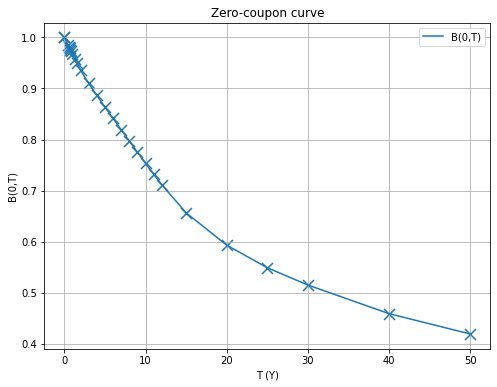

In [54]:
B = get_term_structure(quotes)

ax = plot_term_structure(
    B, 
    "B(0,T)",
    title="Zero-coupon curve",
    )

<u> **Comments :** </u>

The curve starts around 1 and is decreasing thereon which is in line with the concept of time-value of money : the sooner the cash flow, the more valuable.

### 1.2. Get the flat spot rate curve :

Then, it is possible then to deduce the rate for each coresponding maturity with the formula : $r_{T} = -\frac{ln(B(0,T))}{T}$.

This is an approximation as it considers the rate as deterministic and constant through time for each maturity. It is a flat rate.

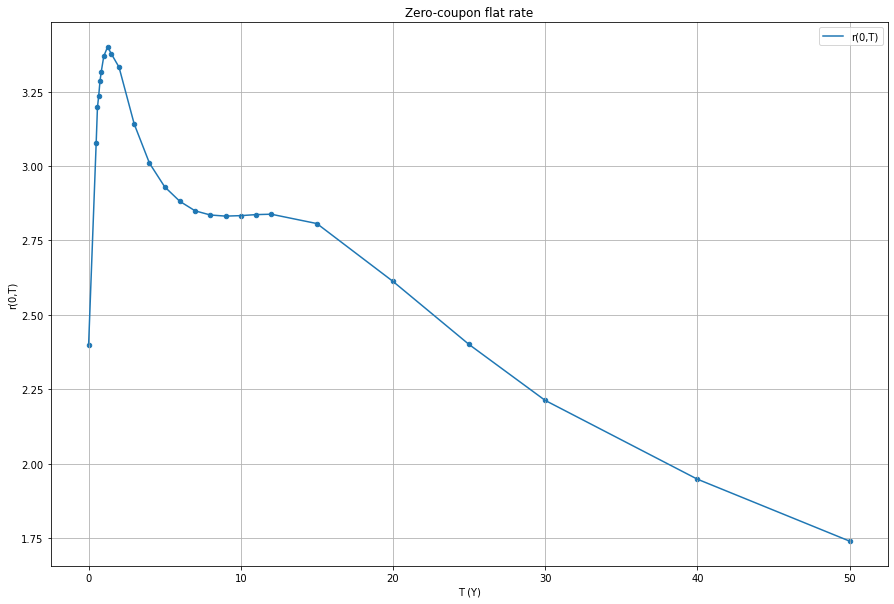

In [5]:
R = get_rates_from_zero_coupons(B)
ax = plot_term_structure(
    R, 
    "r(0,T)",
    title="Zero-coupon flat rate",
    )

<u> **Comments** </u> 

An increasing curve is expected for the zero-coupon interest rate as the longer the maturity, the bigger the risk and the longer the funds are unavailable for the lender.

It is the case for maturities up to two years. After two years, the non-increasing property of the curve is problematic in the modelisation of rates as it contradicts the no-arbitrage assumption : one can sell bonds with long maturities and buy bonds with shorter maturities, even maybe with a roll-over strategy, receiving in the end a higher interst rate than what will be required to cash back for the long-maturity bond.

In practice arbitrage might not actually be possible due to liquidity or fee issues.

Still, this curve illustrates how the interpolation has been carried out when building the ZC curve.

Indeed, the interpolated flat rate for the new maturity is exactly this curve (linear interpolation between each point).

### 1.3. Get the instantaneous forward rate curve :

Then, it is possible to determine the insantaneous forward-rate curve with the formula :

$$ f_{T, T+\delta}(0) = \frac{B(0,T)-B(0,T+\delta)}{\delta B(0,T+\delta)} $$

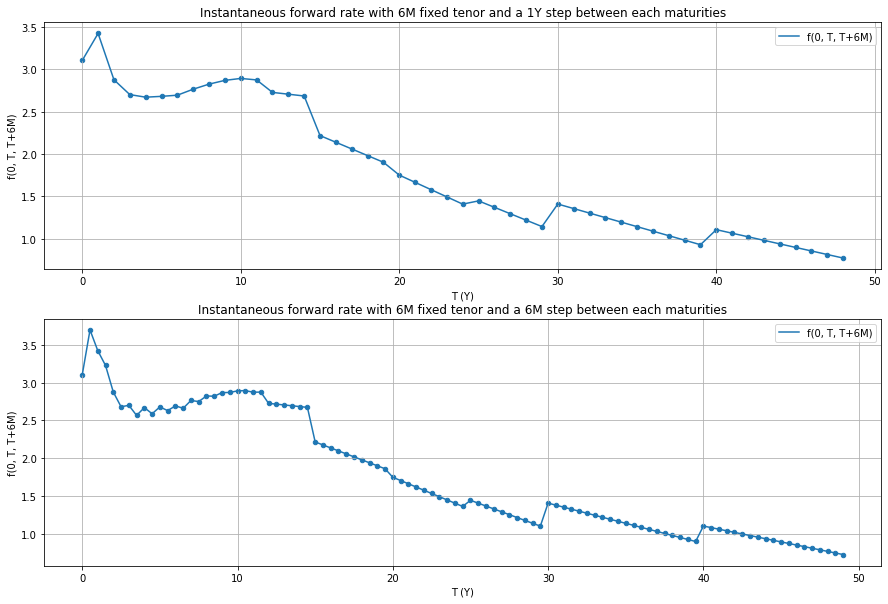

In [6]:
# get only bond values up to just above 10Y (for interpolation)
B_subset = B.copy() 

F_1Y_step_6M_tenor = compute_forward_curve(B_subset, tenor=.5, step=1.)
F_6M_step_6M_tenor = compute_forward_curve(B_subset, tenor=.5, step=.5)


# plot the forward rate
_, axs = plt.subplots(figsize=(15,8), nrows=2)

_ = plot_term_structure(
    F_1Y_step_6M_tenor, 
    "f(0, T, T+6M)",
    title="Instantaneous forward rate with 6M fixed tenor and a 1Y step between each maturities",
    ax=axs[0])

_ = plot_term_structure(
    F_6M_step_6M_tenor, 
    "f(0, T, T+6M)",
    title="Instantaneous forward rate with 6M fixed tenor and a 6M step between each maturities",
    ax=axs[1])

<u>**Comments :**</u>

The forward rate curve with 6M fixed-tenor presents discontinuities after 10Y. This is rather a modelisation issue than the proof of an arbitrage opportunity.

There is also a see-saw phenomenon between year 3 and year 8 when the step between each maturity is smaller than the tenor. This can be caused by an approximation error in the linear interpolation of the log of zero-coupon bonds. 

The curve is overall decreasing. This is coherent with the idea that profits arriving at a remote horizon are less valuable than short-term cash flows.

As a sanity check, the following cell verifies that the 6M cash-rate from the initial quotes equals the forward rate with maturity zero and tenor 6M :

In [7]:
cash_rates = quotes.loc[quotes["Rate Type"]=="Cash Rates"]
cash_rates.loc[cash_rates["Term"]==6][["Mid"]]

,Mid
1,3.102


In [8]:
F_6M_step_6M_tenor.loc[F_6M_step_6M_tenor["Maturity (Y)"]==0.][["f(0, T, T+6M)"]]

,"f(0, T, T+6M)"
0,3.102


## 2. Hull-White model

### 2.1 Swaption price calibration

#### <u>Products definition : </u>

- **European Swaption** : 

It is an option on an interest rate swap with only one exercice date.

- **Bermudean Swaption** : 

It is an option on an interest rate swap that can be exercised at multiple predetermined dates.

#### <u> Comments on the options volatility table : </u> 

The index of the table ("Expiry") corresponds to the exercice tenor of the option - caplet here. 

The columns correspond to the different maturities of the underlying swap.

#### <u> Pricing approach :</u>

It is natural to calibrate the Bermudean swaption with 1x3, 2x2 and 3x1 standard swaptions.

Indeed, at each exercice date, a choice has to be made on whether it is more profitable to exercise the option or to wait. 

The comparison has to be made with the corresponding underlying (a swaption starting at the potential exercise date and ending at the fixed maturity). 


### 2.2 Hull-White model calibration

The approach is to bootstrap the term structure of the volatility with the Bloomberg quotes to price the 1x4 Bermudean swaption.

It will be assumed that volatility is constant between each exercise date.

To do so, the Jamshidian trick will be applied to the observed swaptions.

For a given swaption, one can see it as a put option on a coupon-bearing bond.

$$ \text{Swaption}(t,T_{0}, (T_{i})) = B(t,T_{0})\sum_{k=1}^{n}c_{k}\pi_{k}$$

With $c_{k} = \delta_{k}K, \ \ k = 1 \ ...\ n-1 $, and $c_{n} = 1+\delta_{n}K$.

$\pi_{k}$ is the value of a put option on a zero-coupon bond of expressed in the $T_{0}$-forward measure (exercice date of the swaption).

To compute the synthetic strikes of the put options, one has to find the root of :

$$ f(y) = K - \sum_{k=1}^{n}c_{k}e^{\mu (T_{0}, T_{k})-\psi (T_{0}, T_{k})y}$$

With $ K = B(0, T_{0}) $ in our case.

And then :

$$ K_{k} = e^{\mu (T_{0}, T_{k})-\psi (T_{0}, T_{k})\bar{y}}$$

is the strike of each put option.


In [9]:
def gamma(t, T, sigma, lamb):
    return sigma*(np.exp(-lamb*(T-t))-1)/lamb

def beta(t,T,l):
    return (1-np.exp(-l*(T-t)))/l

def phi(t, sigma:list, l:float):
    """ sigma is piecewise constant with a step of 1 and t belongs to 1 , 4"""
    # TODO : what is the value of sigma between 0 and 1Y ? considered zero for now
    p = 0.
    y = 1
    while y+1 <= t:
        p += sigma[y-1]**2/(2*l)*(np.exp(-2*l*(t-y-1))-np.exp(-2*l*(t-y)))
        y += 1
    p += sigma[y-1]**2/(2*l)*(1.-np.exp(-2*l*(t-y)))
    return p

def find_root(f, x0, precision):
    """ Apply Newton method to find a root """
    x = x0
    while f(x) == f(x0):
        x += 1.
    while np.abs(x-x0)>precision:
        x, x0 = x+f(x)*(x-x0)/(f(x0)-f(x)), x
    return x

def black_put(S0:float, sigma:float, T:float, K:float)->float:
    """ Black formula for a put option """
    d1 = (np.log(S0/K)+sigma**2*T/2.)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return -S0*np.linalg.norm(-d1)+K*np.linalg.norm(-d2)

def bootstrap_implicit_volatility(obs_vol:dict):
    """ Compute the implicit volatility structure given observed volatility of ?"""
    sigma = [obs_vol[(1,3)]/9]
    sigma.append(np.sqrt(.5*obs_vol[(2,2)]**2-sigma[-1]**2))
    sigma.append(np.sqrt(3*obs_vol[(3,1)]**2-sigma[-1]**2-sigma[-2]**2))
    return sigma

def plot_piecewise_constant(Y:list, X:list, title:str, xlabel:str, ylabel:str):
    _, ax = plt.subplots(figsize=(8, 6))
    ax.step(X, [Y[0]] + Y)
    ax.grid()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    return ax

In [10]:
# define inputs
l = .03

swaptions_vol = {
    (1,3): 41.35/100,
    (2,2): 41.71/100,
    (3,1): 40.81/100
}

ZC = B.set_index("Maturity (Y)")

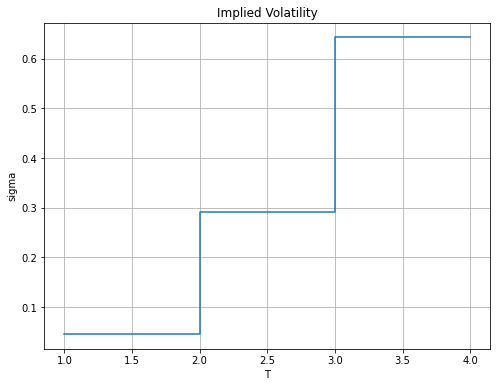

In [11]:
# bootstrap volatility
sigma = bootstrap_implicit_volatility(swaptions_vol)

# plot volatlity
_ = plot_piecewise_constant(
    sigma,
    range(1,5),
    "Implied Volatility",
    "T",
    "sigma"
)

To determine $x_{Jamshidian}$, the swaptions strike have to be known.

The strike of the underlying interest rate swap can be evaluated with the following formula :

$$K_{swap} = \frac{B(0,T_{0}) - B(0, T_{n})}{\sum_{k=1}^{n}\delta_{k}L(0, T_{k-1}, T_{k})} $$

Which flows from the fact that a swap is worth zero at initiation.

The values $L(0, T_{k-1}, T_{k})$ can be deduced from the zero-coupon curve.

In [12]:
# determine what the strike of the swaptions should be
F_1Y_step_1Y_tenor = compute_forward_curve(B_subset, tenor=1., step=1.).set_index("Maturity (Y)")

def get_swap_strike(swap:tuple, ZC:pd.Series, forward_rates:pd.Series):
    t = swap[0]
    T = t + swap[1]
    return float(ZC.loc[t]-ZC.loc[T])/float(forward_rates.loc[t:(T+1)].sum())

K = {
    (1,3): get_swap_strike((1,3), ZC, F_1Y_step_1Y_tenor),
    (2,2): get_swap_strike((2,2), ZC, F_1Y_step_1Y_tenor),
    (3,1): get_swap_strike((3,1), ZC, F_1Y_step_1Y_tenor),
}

In [13]:
def price_swaption(terms:tuple, zc:pd.Series, vols:dict, sigma:list):
    """ Use Jamshidian's trick to price swaption txT with yearly payments"""
    # maturity and number of cash flows
    T0 = terms[0]
    N = terms[1]
    # define the synthetic coupon-bearing bond
    c = np.ones(N)*K[terms]
    c[-1] += 1
    # find x Jamshidian
    f = lambda y : float(zc.loc[T0]) - np.sum([c[k-1]*float(zc.loc[k+T0]/zc.loc[T0])*np.exp(-.5*beta(T0, T0+k, l)*phi(T0, sigma, l)-beta(T0, T0+k, l)*y) for k in range(1,N+1)])
    x_jam = find_root(f, 0.5, 0.2)
    # deduce the k_i thanks to Jamshidian's trick
    k = [float(c[i-1]*zc.loc[i+T0]/zc.loc[T0]*np.exp(-.5*beta(T0, T0+i, l)*phi(T0, sigma, l)-beta(T0, T0+i, l)*x_jam)) for i in range(1,N+1)]
    # apply Black formula to find put prices
    pi = [-black_put(float(zc.loc[T0+i]/zc.loc[T0]), vols[terms], T0, k[i-1]) for i in range(1, N+1) ]
    # deduce the swaption price according the Jamshidian's decomposition
    return float(zc.loc[terms[0]])*np.sum([c[i]*pi[i] for i in range(N)])

def price_swaptions(vols:dict, zc:pd.Series, sigma:list):
    # swaptions pricing
    swaption_prices = {}
    for swap in vols.keys():
        # deduce the swaption price
        swaption_prices[swap] = price_swaption(swap, zc, vols, sigma)
    return swaption_prices


In [14]:
swaption_prices = price_swaptions(swaptions_vol, ZC, sigma)

In [15]:
s_p = pd.DataFrame({"Swaption Prices":pd.Series(swaption_prices)})
s_p.index.name = "t,T"
s_p

,,Swaption Prices
1,3,9.506219
2,2,3.277510
3,1,0.142496


### 2.3 Bermudean swaption pricing

$X_{t}$ is an Ornstein-Uhlenbeck process whose parameters are now all known.

Applying Itô's lemma, the value function of the Bermudean swaption follows the following PDE between each exercice date :

$$ r v(t,x) = \partial_{t}v(t,x) + \frac{\sigma^{2}(t)}{2}\partial^{2}_{xx}v(t,x) + (\phi(t) - \lambda x)\partial_{x}v(t,x) $$

With the following limit conditions :

$$
\begin{cases}
v(1Y, x) >= \text{max}(\text{Swap}(3Y, x)^{+}, \text{Swaption}(1Y, 2Y, x)^{+}, \text{Swaption}(2Y, 1Y, x)^{+})\\
v(2Y, x) = \text{max}(\text{Swap}(2Y, x)^{+}, \text{Swaption}(1Y, 1Y, x)^{+})\\
v(3Y, x) = \text{Swap}(1Y, x)^{+}\\
\end{cases}
$$

Where the strikes of the swaps is 45% (from the Bloomberg table) therefore the swaps are not at the money and their value is not zero.

<u>**Comments on the value at 1Y :**</u>

After one year, the value condition of the Bermudean option is an inequality because at year two, there will still be more than two options. Therefore the value is above the max of the values of the underlying options as the optionnality at year 2 is only provided by the Bermudean option.

Say at year 1, the maximum value of $\text{Swap}(3Y, x)^{+}, \text{Swaption}(1Y, 2Y, x)^{+}, \text{Swaption}(2Y, 1Y, x)^{+}$ is $\text{Swaption}(1Y, 2Y, x)^{+}$. If the price of the Bermudean option equals the value of this product, they should be equivalent in time, knowing that one is a subcontract of the other.

Say that at year 2, the odds have changed and $\text{Swaption}(1Y, 1Y, x)^{+}$ has a greater value than $\text{Swap}(2Y, x)^{+}$ (that is what has become of the underlying of max-value swaption at year 1).

The Bermudean portfolio will have the value of the swaption between year 3 and 4, whereas the normal swaption will have the value of the two-year swap starting at year 2.

Thus, the Bermudean option value at year one is different from $\text{max}(\text{Swap}(3Y, x)^{+}, \text{Swaption}(1Y, 2Y, x)^{+}, \text{Swaption}(2Y, 1Y, x)^{+})$. As the former contains the latter, it should be greater.

### Forward zero-coupon term structure

As $\sigma$ is calibrated with the Hull-White model, it is possible to apply a Monte-Carlo method to deduce the values of $B(t,T)$ for $t$ and $T$ between zero and four.

In [16]:
def integral(f, t, T, h=0.01):
    N = floor((T-t)/h)
    i = 0.
    for k in range(N):
        i += f(t+(T-t)*h*k/N)*h
    return i

def get_forward_ZC_curve_MC(t,T,sigma, ZC, l, n_sim):
    zc = [1.]
    for T_i in range(t+1, T+1):
        mean_X = integral(lambda s: np.exp(-l*(T_i-s))*phi(s, sigma, l), t, T_i)
        var_X = integral(lambda s: np.exp(-2*l*(T_i-s))*sigma[floor(s)-1]**2, t, T_i)

        X = np.random.normal(loc=mean_X, scale=var_X, size=n_sim)

        ZC_ratio = float(ZC.loc[T_i])/float(ZC.loc[t])

        B_t_T_sims = ZC_ratio*np.exp(-beta(t,T_i,l)**2*phi(t, sigma, l)/2.-beta(t, T_i, l)*X)
        B_t_T = np.mean(B_t_T_sims)
        zc.append(B_t_T)
    return pd.Series(zc, index=range(t, T+1))
        

In [17]:
Z = get_forward_ZC_curve_MC(3, 4, sigma, ZC, l, 1000)

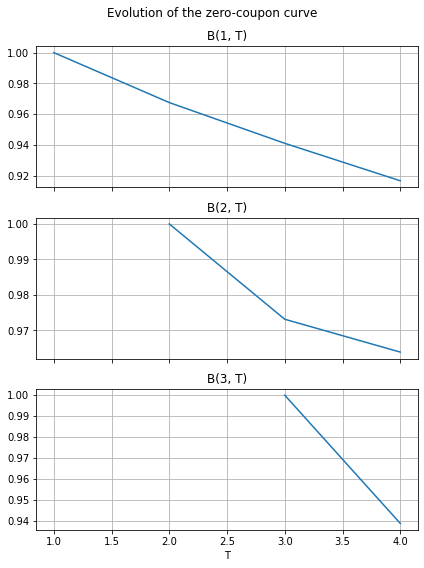

In [18]:
def plot_ZC_evolution(t, T, sigma, ZC, l, n_sim):
    fig, axs = plt.subplots(nrows=T-t, figsize=(6, 8), sharex=True)
    fig.suptitle("Evolution of the zero-coupon curve")
    for i in range(t, T):
        curve = get_forward_ZC_curve_MC(i, T, sigma, ZC, l, n_sim)
        curve.plot(ax=axs[i-t], title="B({}, T)".format(i), xlabel="T", grid=True)
    fig.tight_layout()
    return axs

axs = plot_ZC_evolution(1, 4, sigma, ZC, l, 2000)

These curve would allow the pricing of the underlying products that intervene in the limit conditions of the Bermudean valuation PDE.